# Australian Retail: Customer Segmentation using RFM Analysis

## Business Problem
An Australian retailer wants to identify high-value customers, detect churn risk,
and improve retention strategy using transactional data.

## Objective
Use RFM Analysis (Recency, Frequency, Monetary) to segment customers into:
- Champions
- Loyal Customers
- Potential Loyalists
- New Customers
- At Risk
- Lost

**Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn

In [35]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set(style='whitegrid')

In [36]:
# Load Data
df = pd.read_csv('../data/australian_retail_rfm_sample.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

print(f"Shape: {df.shape}")
print(f"Date range: {df['order_date'].min().date()} → {df['order_date'].max().date()}")
df.head()

Shape: (1400, 14)
Date range: 2024-01-01 → 2025-03-31


,order_id,customer_id,order_date,suburb,state,postcode,product_category,quantity,unit_price_aud,discount_pct,shipping_fee_aud,sales_channel,payment_method,net_revenue_aud
0,ORD00983,CUST0138,2024-01-01,Sydney,NSW,2000,Fashion,2,133.68,20,4.99,In-Store,Apple Pay,218.88
1,ORD00668,CUST0207,2024-01-01,Sydney,NSW,2000,Groceries,3,23.63,5,7.99,Online,Mastercard,75.34
2,ORD00368,CUST0079,2024-01-01,Cairns,QLD,4870,Pet Care,2,86.55,0,0.00,In-Store,Apple Pay,173.10
3,ORD01101,CUST0192,2024-01-01,Mount Gambier,SA,5290,Household,1,27.10,0,12.99,Online,PayPal,40.09
4,ORD01201,CUST0200,2024-01-02,Townsville,QLD,4810,Household,1,84.06,5,0.00,Online,Visa,79.86


In [37]:
# Data Overview
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Stats ===")
df[['quantity', 'unit_price_aud', 'net_revenue_aud']].describe().round(2)

=== Missing Values ===
order_id            0
customer_id         0
order_date          0
suburb              0
state               0
postcode            0
product_category    0
quantity            0
unit_price_aud      0
discount_pct        0
shipping_fee_aud    0
sales_channel       0
payment_method      0
net_revenue_aud     0
dtype: int64

=== Data Types ===
order_id                    object
customer_id                 object
order_date          datetime64[ns]
suburb                      object
state                       object
postcode                     int64
product_category            object
quantity                     int64
unit_price_aud             float64
discount_pct                 int64
shipping_fee_aud           float64
sales_channel               object
payment_method              object
net_revenue_aud            float64
dtype: object

=== Basic Stats ===


,quantity,unit_price_aud,net_revenue_aud
count,1400.00,1400.00,1400.00
mean,1.98,104.15,194.80
std,1.21,139.03,305.23
min,1.00,7.80,7.89
25%,1.00,33.75,53.62
50%,2.00,59.28,102.66
75%,3.00,110.22,213.62
max,5.00,922.47,3892.30


## 📊 Exploratory Data Analysis
Before building the RFM model, let's understand the data at a high level.
- How many unique customers do we have?
- What states are they from?
- What is the revenue distribution?

In [38]:
# EDA
print(f"Total Orders:     {df['order_id'].nunique():,}")
print(f"Total Customers:  {df['customer_id'].nunique():,}")
print(f"Total Revenue:    AUD {df['net_revenue_aud'].sum():,.2f}")
print(f"Avg Order Value:  AUD {df['net_revenue_aud'].mean():,.2f}")

print("\n--- Revenue by State ---")
state_rev = df.groupby('state')['net_revenue_aud'].sum().sort_values(ascending=False)
print(state_rev.apply(lambda x: f"AUD {x:,.2f}"))

Total Orders:     1,400
Total Customers:  220
Total Revenue:    AUD 272,713.15
Avg Order Value:  AUD 194.80

--- Revenue by State ---
state
NSW    AUD 78,020.47
VIC    AUD 73,054.14
WA     AUD 51,975.52
QLD    AUD 40,880.16
SA     AUD 15,559.91
ACT    AUD 13,222.95
Name: net_revenue_aud, dtype: object


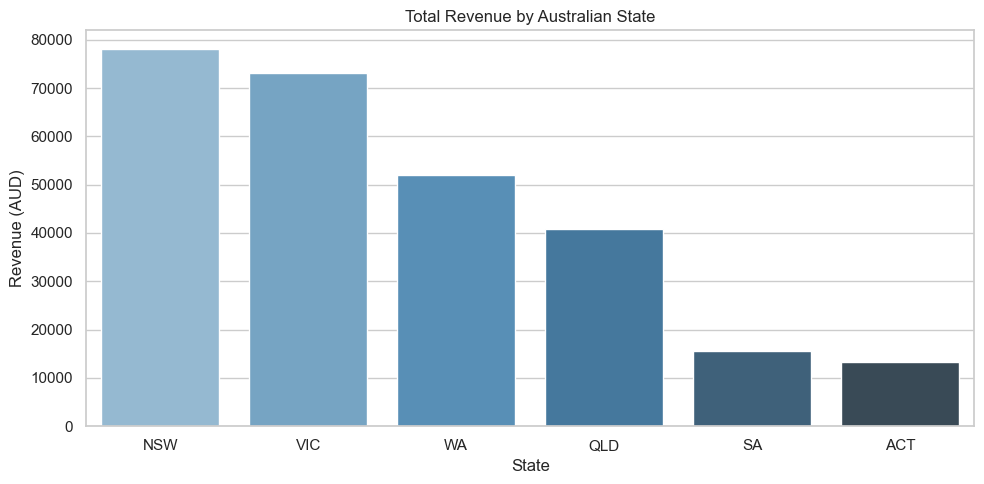

In [39]:
# Revenue by State
plt.figure(figsize=(10, 5))
sns.barplot(x=state_rev.index, y=state_rev.values,
            hue=state_rev.index, palette='Blues_d', legend=False)
plt.title('Total Revenue by Australian State')
plt.xlabel('State')
plt.ylabel('Revenue (AUD)')
plt.tight_layout()
plt.savefig('../visuals/revenue_by_state.png', dpi=200)
plt.show()

## 🧮 Step 1: Calculate RFM Metrics

| Metric | Definition |
|---|---|
| **Recency** | Days since the customer's last purchase |
| **Frequency** | Total number of unique orders |
| **Monetary** | Total revenue generated (AUD) |

In [40]:
# Build RFM Table
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency  = ('order_date',      lambda x: (snapshot_date - x.max()).days),
    frequency= ('order_id',        'nunique'),
    monetary = ('net_revenue_aud', 'sum')
).reset_index()

print(f"✅ RFM table: {rfm.shape[0]} customers")
rfm.head(10)

✅ RFM table: 220 customers


,customer_id,recency,frequency,monetary
0,CUST0001,37,5,4504.35
1,CUST0002,243,7,400.20
2,CUST0003,135,4,251.68
3,CUST0004,13,8,2683.08
4,CUST0005,33,8,1015.92
5,CUST0006,43,6,1273.49
6,CUST0007,54,3,684.58
7,CUST0008,26,5,832.77
8,CUST0009,28,10,1369.62
9,CUST0010,2,7,734.18


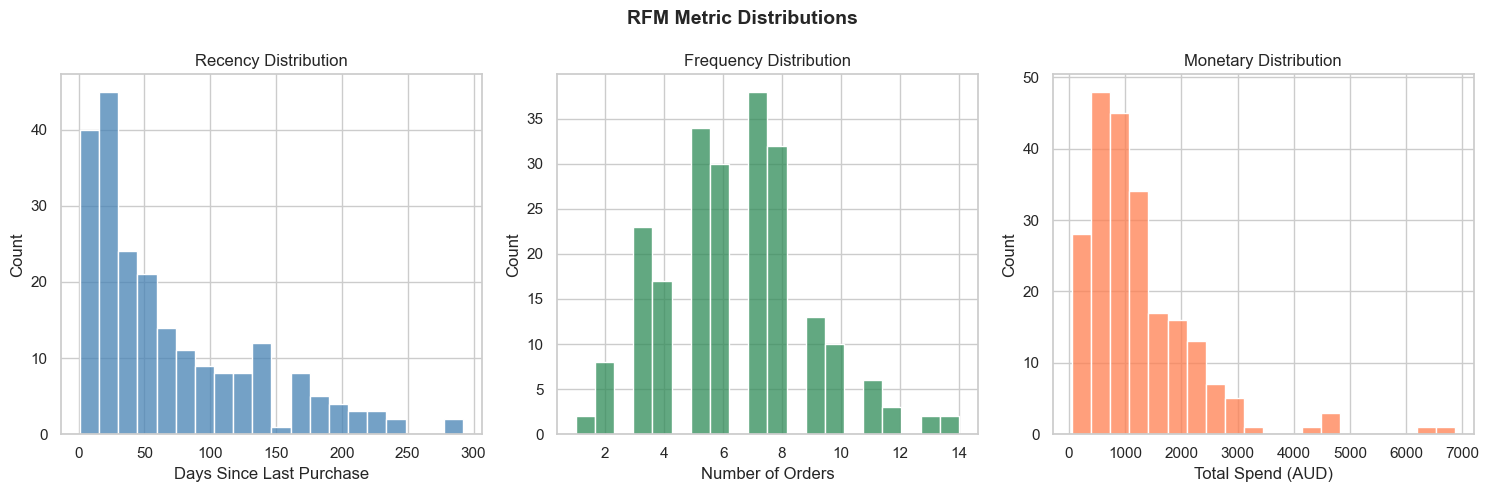

In [41]:
# RFM Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm['recency'],   ax=axes[0], color='steelblue', bins=20)
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['frequency'], ax=axes[1], color='seagreen',  bins=20)
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')

sns.histplot(rfm['monetary'],  ax=axes[2], color='coral',     bins=20)
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spend (AUD)')

plt.suptitle('RFM Metric Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/rfm_distributions.png', dpi=200)
plt.show()

## 🏆 Step 2: Assign RFM Scores (1–5)
Each customer is scored from **1 to 5** on each metric:
- **Recency:** 5 = purchased very recently, 1 = purchased long ago
- **Frequency:** 5 = purchases very often, 1 = rarely purchases
- **Monetary:** 5 = highest spender, 1 = lowest spender

In [42]:
# Assign Scores
rfm['R'] = pd.qcut(rfm['recency'],
                    5, labels=[5, 4, 3, 2, 1],
                    duplicates='drop').astype(int)

rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'),
                    5, labels=[1, 2, 3, 4, 5],
                    duplicates='drop').astype(int)

rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),
                    5, labels=[1, 2, 3, 4, 5],
                    duplicates='drop').astype(int)

rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_total'] = rfm['R'] + rfm['F'] + rfm['M']

rfm.head(10)

,customer_id,recency,frequency,monetary,R,F,M,RFM_score,RFM_total
0,CUST0001,37,5,4504.35,3,2,5,325,10
1,CUST0002,243,7,400.20,1,3,1,131,5
2,CUST0003,135,4,251.68,1,1,1,111,3
3,CUST0004,13,8,2683.08,5,4,5,545,14
4,CUST0005,33,8,1015.92,4,4,3,443,11
5,CUST0006,43,6,1273.49,3,2,4,324,9
6,CUST0007,54,3,684.58,3,1,2,312,6
7,CUST0008,26,5,832.77,4,2,3,423,9
8,CUST0009,28,10,1369.62,4,5,4,454,13
9,CUST0010,2,7,734.18,5,3,2,532,10


## 🎯 Step 3: Assign Business Segments
Based on RFM scores, each customer is placed into one of 6 business segments.

In [43]:
# Segment Logic
def segment_logic(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    if r <= 2 and f >= 3:            return 'At Risk'
    if r >= 4 and f <= 2:            return 'New Customers'
    if r <= 2 and f <= 2:            return 'Lost'
    if r >= 3 and f >= 3:            return 'Loyal Customers'
    return 'Potential Loyalists'

rfm['segment'] = rfm.apply(segment_logic, axis=1)

print("Segment Counts:")
print(rfm['segment'].value_counts())

Segment Counts:
segment
Loyal Customers        56
Lost                   45
At Risk                42
Champions              34
New Customers          24
Potential Loyalists    19
Name: count, dtype: int64


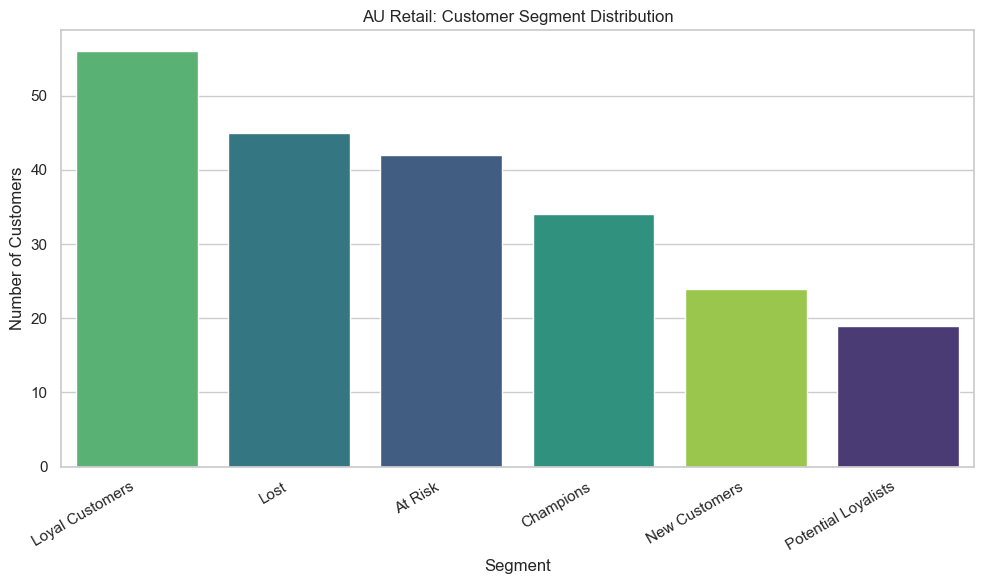

In [44]:
# Segment Distribution Chart
plt.figure(figsize=(10, 6))
order = rfm['segment'].value_counts().index
sns.countplot(data=rfm, x='segment', order=order,
              hue='segment', palette='viridis', legend=False)
plt.title('AU Retail: Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../visuals/segment_distribution.png', dpi=200)
plt.show()

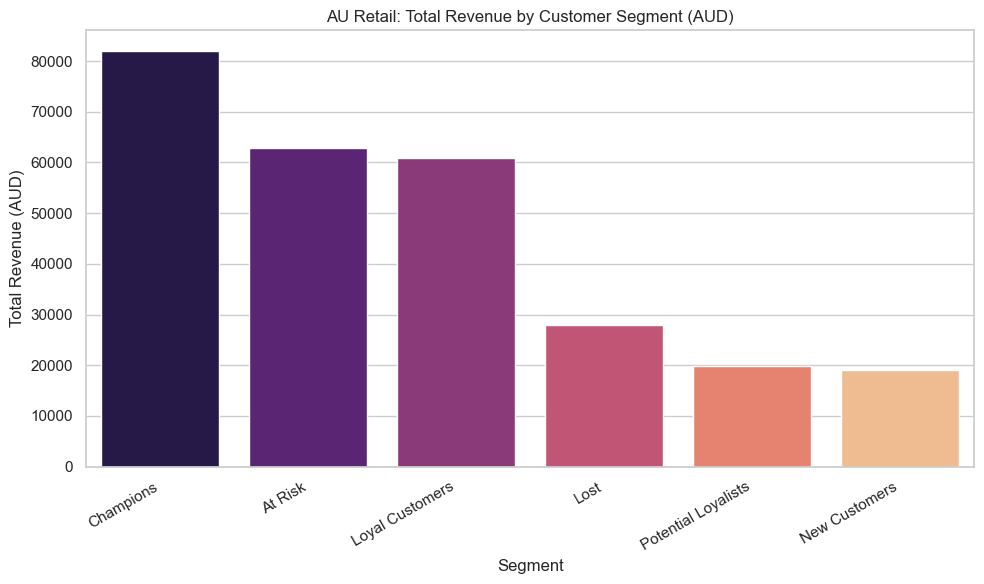

In [45]:
# Revenue by Segment Chart
revenue = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue.index, y=revenue.values,
            hue=revenue.index, palette='magma', legend=False)
plt.title('AU Retail: Total Revenue by Customer Segment (AUD)')
plt.xlabel('Segment')
plt.ylabel('Total Revenue (AUD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../visuals/revenue_by_segment.png', dpi=200)
plt.show()

In [46]:
# Segment Summary Table
summary = rfm.groupby('segment').agg(
    num_customers     = ('customer_id', 'count'),
    avg_recency_days  = ('recency',     'mean'),
    avg_orders        = ('frequency',   'mean'),
    avg_revenue_aud   = ('monetary',    'mean'),
    total_revenue_aud = ('monetary',    'sum')
).round(2).sort_values('total_revenue_aud', ascending=False)

summary['revenue_share_pct'] = (
    summary['total_revenue_aud'] / summary['total_revenue_aud'].sum() * 100
).round(2)

summary

,num_customers,avg_recency_days,avg_orders,avg_revenue_aud,total_revenue_aud,revenue_share_pct
segment,,,,,,
Champions,34,15.56,9.44,2410.55,81958.55,30.05
At Risk,42,112.26,7.57,1496.78,62864.78,23.05
Loyal Customers,56,31.62,7.36,1087.91,60923.23,22.34
Lost,45,152.11,3.69,622.12,27995.51,10.27
Potential Loyalists,19,48.58,4.42,1043.32,19823.13,7.27
New Customers,24,12.42,4.12,797.83,19147.95,7.02


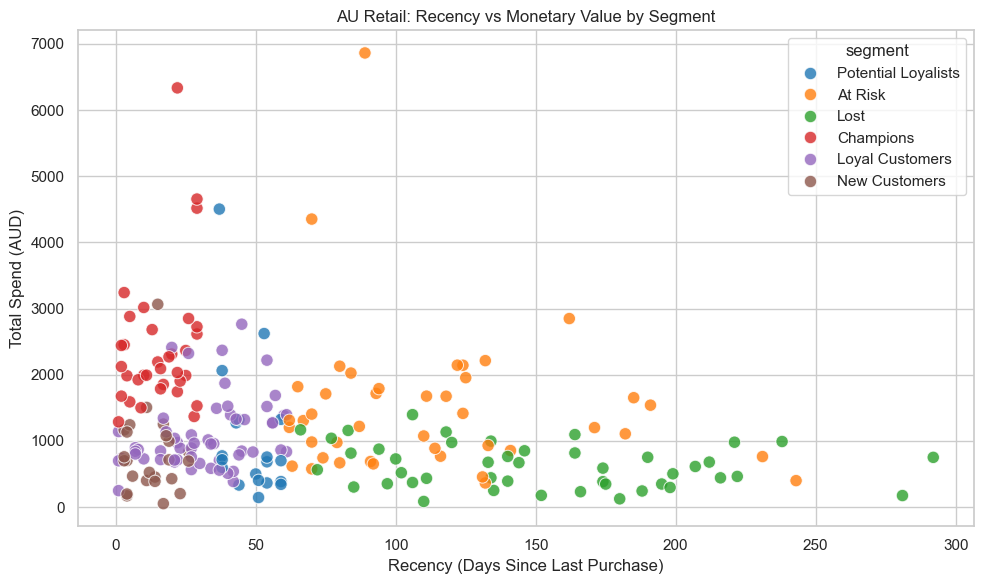

In [47]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='recency', y='monetary',
                hue='segment', palette='tab10', s=80, alpha=0.8)
plt.title('AU Retail: Recency vs Monetary Value by Segment')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Total Spend (AUD)')
plt.tight_layout()
plt.savefig('../visuals/recency_vs_monetary.png', dpi=200)
plt.show()

In [48]:
# Top Customers 
top_customers = rfm.sort_values(
    ['RFM_total', 'monetary'], ascending=[False, False]
).head(10)

top_customers[['customer_id', 'recency', 'frequency', 'monetary', 'segment']]

,customer_id,recency,frequency,monetary,segment
178,CUST0179,3,14,3242.52,Champions
15,CUST0016,10,9,3017.57,Champions
21,CUST0022,3,13,2453.74,Champions
133,CUST0134,2,8,2443.50,Champions
106,CUST0107,2,9,2124.52,Champions
174,CUST0175,16,9,2092.79,Champions
209,CUST0210,11,12,1993.40,Champions
47,CUST0048,10,10,1993.00,Champions
205,CUST0206,22,10,6336.75,Champions
200,CUST0201,29,9,4656.11,Champions


In [49]:
# Save Outputs
os.makedirs('../outputs', exist_ok=True)

rfm.to_csv('../outputs/rfm_customer_segments.csv', index=False)
summary.to_csv('../outputs/rfm_segment_summary.csv')
top_customers.to_csv('../outputs/rfm_top_customers.csv', index=False)

print("✅ All outputs saved to /outputs folder")

✅ All outputs saved to /outputs folder


## 💡 Key Business Insights

### 1. Champions Drive Disproportionate Revenue
The **Champions** segment contributes ~30% of total revenue despite being a small group.
These customers should be rewarded with VIP loyalty programs.

### 2. At Risk Segment is a Major Opportunity
Over **AUD 62,000** in revenue sits in the At Risk category.
A targeted win-back campaign could recover a significant portion of this.

### 3. NSW and VIC are the Strongest Markets
Over 55% of total revenue comes from NSW and VIC.
Regional campaigns should prioritize these two states.

## 🚀 Recommendations

| Segment | Action |
|---|---|
| Champions | VIP loyalty program, early access to sales |
| At Risk | Win-back email with discount voucher |
| Loyal Customers | Reward points, referral program |
| Potential Loyalists | Bundle offers, second purchase discount |
| New Customers | Welcome series, onboarding discount |
| Lost | Low-cost reactivation campaign |